In [2]:
!pip install git



ERROR: Could not find a version that satisfies the requirement git (from versions: none)
ERROR: No matching distribution found for git


In [4]:
!git init


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `Delgado David`
- Apellido2, Nombre2: `Moreno Jose `

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [7]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1000655159
cedula2 = 1001368426

In [8]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 585
Parámetros — alpha: 2.20, beta: 1.00, gamma: 0.140, ruido: 0.050
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

a. Significa que el spline pasa exactamente por cada uno de los 225 valores de z_data, porque el spline es interpolante, al agregarle ruido va a causar que la función que devuelva el spline pueda cambiar abruptamente de la original


b. En condiciones donde se sabe que se tiene ruido y/o se conoce que se tienen muchos más datos que el valor del rango dela base asociada a la solución del problema Ac = y

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

**a)** La matriz $A$ tiene 225 filas (una por cada punto $(x_i, y_i)$ de la malla aplanada) y 3 columnas:
- Columna 1: todos unos → coeficiente del término constante $c_0$
- Columna 2: valores de $x_i$ → coeficiente de $c_1$
- Columna 3: valores de $y_i$ → coeficiente de $c_2$

Es decir, $A = [\mathbf{1}, \mathbf{x}, \mathbf{y}]$ donde cada columna es un vector de 225 elementos.

**b)** El plano ajustado es la mejor aproximación lineal a los datos en el sentido de mínimos cuadrados. Los coeficientes c1c_1
c1​ y c2c_2
c2​ informan sobre la tendencia de primer orden de la superficie: si son cercanos a cero, como ocurre aquí debido a la antisimetría del seno, significa que no hay inclinación neta dominante en ninguna dirección

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

a. PCA busca las direcciones de máxima varianza en los datos. Si no se centra, la primera componente principal puede capturar simplemente el desplazamiento de la media, en lugar de la dirección de mayor dispersión real.

b. PC1 apunta en la dirección del espacio (x,y,z)a lo largo de la cual los 225 puntos tienen mayor dispersión. Geométricamente, es el eje que mejor describe la elongación principal de la nube

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [9]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina
# P2.1: construir el spline bicúbico y evaluar en malla fina
from scipy.interpolate import RectBivariateSpline

# Construir el spline interpolante bicúbico (kx=3, ky=3)
spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# Malla fina 100x100
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# Evaluar el spline en la malla fina
Z_spline = spline(x_fine, y_fine)

print(f"Malla fina shape: {Z_spline.shape}")
print(f"Z_spline rango: [{Z_spline.min():.4f}, {Z_spline.max():.4f}]")
print(f"Z_data  rango:  [{Z_data.min():.4f},  {Z_data.max():.4f}]")

Malla fina shape: (100, 100)
Z_spline rango: [-0.9506, 0.9133]
Z_data  rango:  [-0.8757,  0.8653]


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

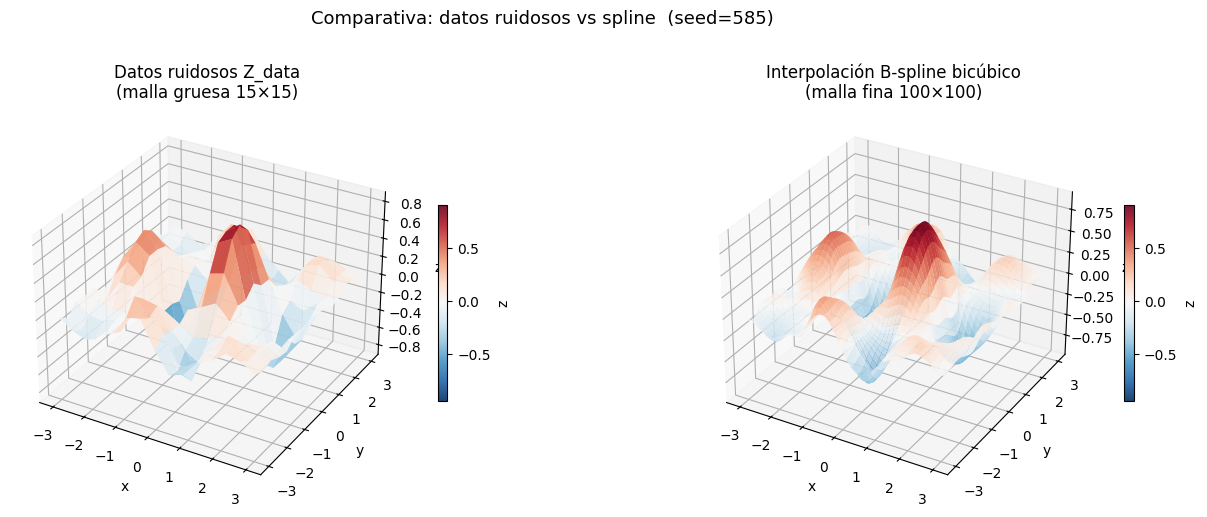

Figura guardada como p2_comparativa.png


In [11]:
# TODO P2.2: figura comparativa datos vs spline
# P2.2: figura comparativa datos vs spline
vmin = min(Z_data.min(), Z_spline.min())
vmax = max(Z_data.max(), Z_spline.max())

fig = plt.figure(figsize=(14, 5))

# Panel izquierdo: Z_data en malla gruesa
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap='RdBu_r',
                          vmin=vmin, vmax=vmax, alpha=0.9)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title(f'Datos ruidosos Z_data\n(malla gruesa {n}×{n})')
fig.colorbar(surf1, ax=ax1, shrink=0.5, label='z')

# Panel derecho: spline en malla fina
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_fine, Y_fine, Z_spline, cmap='RdBu_r',
                          vmin=vmin, vmax=vmax, alpha=0.9)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.set_title('Interpolación B-spline bicúbico\n(malla fina 100×100)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, label='z')

plt.suptitle(f'Comparativa: datos ruidosos vs spline  (seed={seed})', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('p2_comparativa.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura guardada como p2_comparativa.png")

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [12]:
# P3.1: construcción de A y ajuste por mínimos cuadrados
# Aplanar coordenadas y datos
x_flat = X_raw.ravel()      # (225,)
y_flat = Y_raw.ravel()      # (225,)
z_flat = Z_data.ravel()     # (225,)

# Construir la matriz de diseño A: columnas [1, x, y]
A = np.column_stack([np.ones_like(x_flat), x_flat, y_flat])  # (225, 3)
print(f"Forma de A: {A.shape}")

# Resolver por mínimos cuadrados
coef, residuals, rank, sv = np.linalg.lstsq(A, z_flat, rcond=None)
c0, c1, c2 = coef

print(f"\nCoeficientes del plano ajustado  z = c0 + c1·x + c2·y:")
print(f"  c0 = {c0:.4f}   (intercepto)")
print(f"  c1 = {c1:.4f}   (pendiente en x)")
print(f"  c2 = {c2:.4f}   (pendiente en y)")


Forma de A: (225, 3)

Coeficientes del plano ajustado  z = c0 + c1·x + c2·y:
  c0 = -0.0008   (intercepto)
  c1 = -0.0033   (pendiente en x)
  c2 = -0.0006   (pendiente en y)


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

Residuos — media: -0.0000, std: 0.2564, máx abs: 0.8776


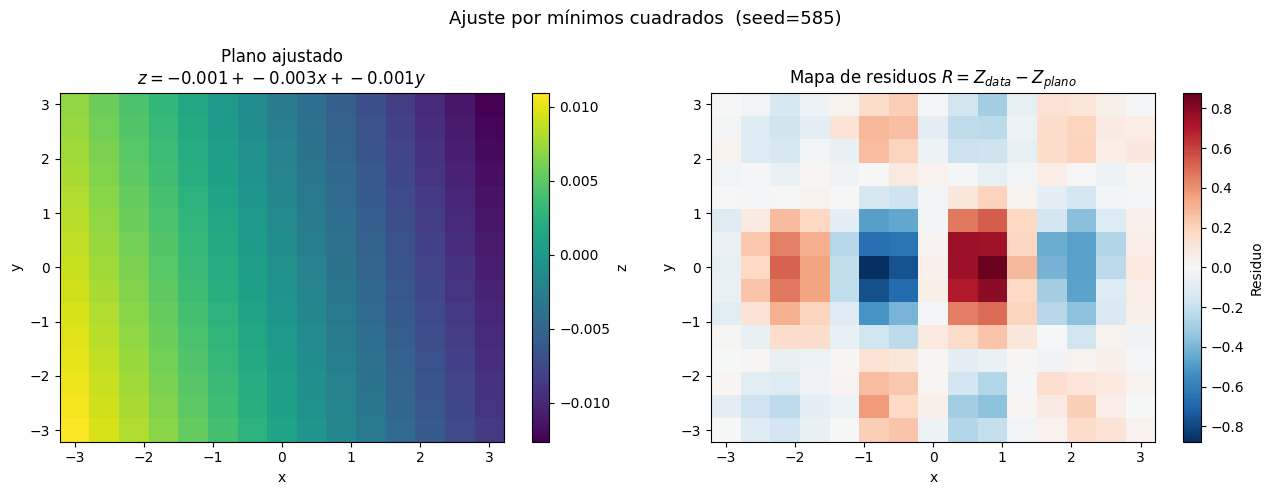

Figura guardada como p3_residuos.png


In [13]:
# P3.2: plano ajustado y mapa de residuos
# Evaluar el plano en la malla gruesa
Z_plane = c0 + c1 * X_raw + c2 * Y_raw   # (15,15)

# Mapa de residuos
R = Z_data - Z_plane

print(f"Residuos — media: {R.mean():.4f}, std: {R.std():.4f}, máx abs: {np.abs(R).max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: plano ajustado
im1 = axes[0].pcolormesh(X_raw, Y_raw, Z_plane, cmap='viridis', shading='auto')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Plano ajustado\n$z = {c0:.3f} + {c1:.3f}x + {c2:.3f}y$')
fig.colorbar(im1, ax=axes[0], label='z')

# Panel derecho: mapa de residuos (colormap divergente centrado en 0)
vlim = np.abs(R).max()
im2 = axes[1].pcolormesh(X_raw, Y_raw, R, cmap='RdBu_r',
                          vmin=-vlim, vmax=vlim, shading='auto')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Mapa de residuos $R = Z_{data} - Z_{plano}$')
fig.colorbar(im2, ax=axes[1], label='Residuo')

plt.suptitle(f'Ajuste por mínimos cuadrados  (seed={seed})', fontsize=13)
plt.tight_layout()
plt.savefig('p3_residuos.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura guardada como p3_residuos.png")



---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [14]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=2.20, omega2=1.00


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

Varianza explicada por componente:
  PC1: 89.85%   acumulada: 89.85%
  PC2: 5.52%   acumulada: 95.37%
  PC3: 0.59%   acumulada: 95.97%
  PC4: 0.49%   acumulada: 96.46%
  PC5: 0.46%   acumulada: 96.92%
  PC6: 0.42%   acumulada: 97.34%
  PC7: 0.37%   acumulada: 97.71%
  PC8: 0.31%   acumulada: 98.02%
  PC9: 0.31%   acumulada: 98.33%
  PC10: 0.29%   acumulada: 98.63%
  PC11: 0.25%   acumulada: 98.88%
  PC12: 0.21%   acumulada: 99.09%


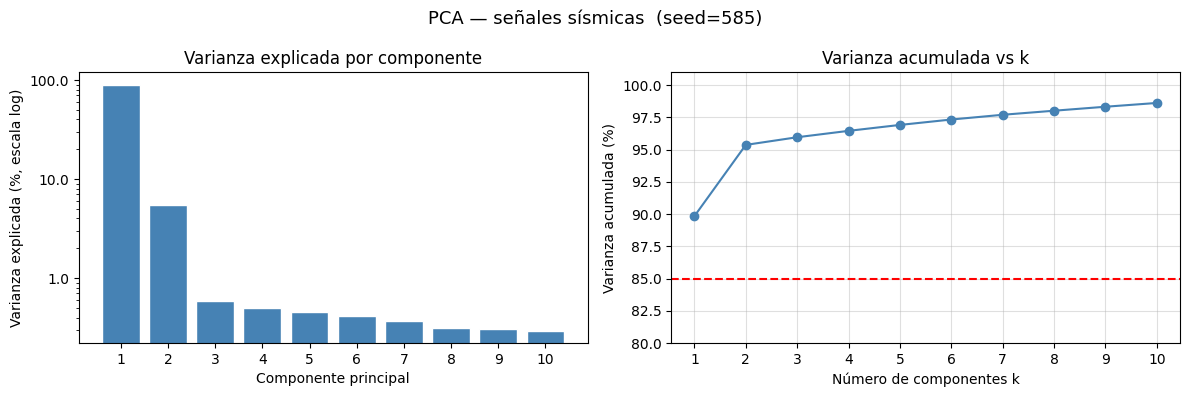

In [29]:
# P4.1: SVD / PCA y varianza explicada

# Centrar las filas (cada sensor es una fila)
X_centered = X - X.mean(axis=1, keepdims=True)

# SVD sobre la matriz centrada  (m × p  →  U: m×m, S: min(m,p), Vt: p×p)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Varianza explicada por cada componente
var_explained = (S**2) / (S**2).sum()
var_cumul = np.cumsum(var_explained)

print("Varianza explicada por componente:")
for i, (ve, vc) in enumerate(zip(var_explained, var_cumul)):
    print(f"  PC{i+1}: {ve*100:.2f}%   acumulada: {vc*100:.2f}%")
    if vc > 0.99:
        break

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel izquierdo: varianza explicada por componente
k_show = min(10, len(S))
axes[0].bar(range(1, k_show+1), var_explained[:k_show] * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%, escala log)')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xticks(range(1, k_show+1))
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))

# Panel derecho: varianza acumulada
axes[1].plot(range(1, k_show+1), var_cumul[:k_show] * 100, 'o-', color='steelblue', markersize=6)
axes[1].axhline(85, color='red', linestyle='--', label='85%')
axes[1].set_xlabel('Número de componentes k')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada vs k')
axes[1].set_xticks(range(1, k_show+1))
axes[1].set_ylim(80, 101)

axes[1].grid(True, alpha=0.4)

plt.suptitle(f'PCA — señales sísmicas  (seed={seed})', fontsize=13)
plt.tight_layout()
plt.savefig('p4_varianza.png', dpi=120, bbox_inches='tight')
plt.show()


### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

Componentes usados para la proyección: k = 2
Varianza acumulada con 2 PCs: 95.37%


/tmp/ipykernel_1291/2459716417.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_disc = plt.cm.get_cmap('plasma', 20)


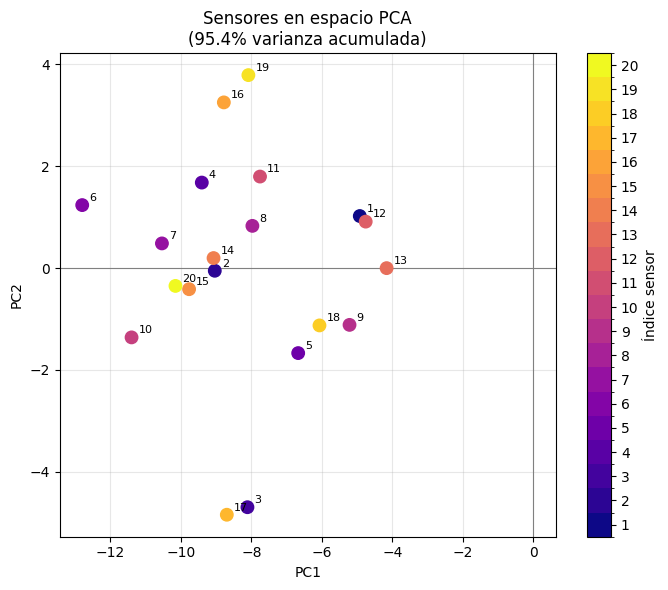

In [32]:
# P4.2: proyección en espacio PCA
# Determinar k: mínimo número de componentes que supera el 89% de varianza
k = int(np.argmax(var_cumul >= 0.89)) + 1
# Garantizar k >= 2 para poder hacer scatter 2D (si ya con 1 se supera el 89%, usamos 2)
k = max(k, 2)
print(f"Componentes usados para la proyección: k = {k}")
print(f"Varianza acumulada con {k} PCs: {var_cumul[k-1]*100:.2f}%")

# Scores: proyectar señales centradas sobre los k primeros PCs
scores = U[:, :k] * S[:k]   # (20, k)
sensor_idx = np.arange(1, m+1)

# Colormap plasma discretizado en 20 colores
import matplotlib.colors as mcolors
cmap_disc = plt.cm.get_cmap('plasma', 20)
norm = mcolors.BoundaryNorm(boundaries=np.arange(0.5, 21.5, 1), ncolors=20)

if k == 2:
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(scores[:, 0], scores[:, 1], c=sensor_idx, cmap=cmap_disc, norm=norm, s=80, zorder=3)
    for i_s in range(m):
        ax.annotate(str(i_s+1), (scores[i_s, 0], scores[i_s, 1]),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(0, color='gray', lw=0.8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Sensores en espacio PCA\n({var_cumul[k-1]*100:.1f}% varianza acumulada)')
    cbar = fig.colorbar(sc, ax=ax, label='Índice sensor')
    cbar.set_ticks(range(1, 21))

else:  # k >= 3
    pairs = [(0,1,'PC1','PC2'), (0,2,'PC1','PC3'), (1,2,'PC2','PC3')]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    sc = None
    for ax, (ii, jj, lx, ly) in zip(axes, pairs):
        sc = ax.scatter(scores[:, ii], scores[:, jj], c=sensor_idx, cmap=cmap_disc, norm=norm, s=80, zorder=3)
        for s_i in range(m):
            ax.annotate(str(s_i+1), (scores[s_i, ii], scores[s_i, jj]),
                        textcoords='offset points', xytext=(4, 3), fontsize=7)
        ax.axhline(0, color='gray', lw=0.8)
        ax.axvline(0, color='gray', lw=0.8)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(lx)
        ax.set_ylabel(ly)
        ax.set_title(f'{lx} vs {ly}')
    fig.suptitle(f'Sensores en espacio PCA (k=3)\n({var_cumul[k-1]*100:.1f}% varianza acumulada)', fontsize=12)
    if sc is not None:
        cbar = plt.colorbar(sc, ax=axes[-1], label='Índice sensor')
        cbar.set_ticks(range(1, 21))

plt.tight_layout()
plt.savefig('p4_scores.png', dpi=120, bbox_inches='tight')
plt.show()

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
